# Gmsh periodic metadata in C++

The native reader supports `$Periodic` in 2.2/4.0/4.1; writers support 2.2/4.1. `GmshInfo` carries raw entity ids, optional affine coefficients and owning Int64 `(N,2)` zero-based point pairs. Sparse file tags resolve to mesh rows; duplicate pairs retain order. Info-less reads refuse periodic files instead of losing pairs. Operations do not remap the channel: rebuild it after point/topology changes. This example mirrors the Python format-parity notebook, using the SVG rendering helper. C++ consumers must rebuild against ABI 22.

In [1]:
#define MESHIOPLUSPLUS_IMPLEMENTATION
#include "../../src/single_include/meshioplusplus/meshioplusplus.hpp"
#include "mio_notebook.hpp"
#include <iostream>
using namespace meshioplusplus;
using namespace mio_nb;

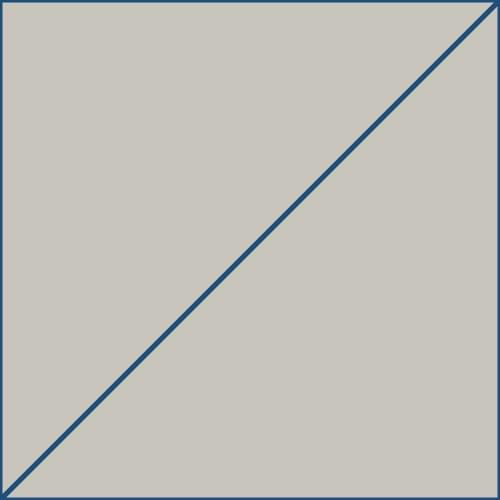

slave row 0 -> master row 1
slave row 2 -> master row 3
slave row 0 -> master row 1


In [2]:
const auto input_path = std::filesystem::temp_directory_path() / "mio_nb_periodic40.msh";
{
    auto out = detail::make_classic_ofstream(input_path.string());
    out << R"($MeshFormat
4.0 0 8
$EndMeshFormat
$Nodes
1 4
22 2 0 4
30 1 0 0
10 0 0 0
40 1 1 0
20 0 1 0
$EndNodes
$Elements
1 2
22 2 2 2
1 10 30 40
2 10 40 20
$EndElements
$Periodic
1
1 2 1
Affine 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1
3
30 10
40 20
30 10
$EndPeriodic
)";
}
GmshInfo info;
auto mesh = read_gmsh(input_path.string(), info);
const auto* pairs = info.mPeriodic.at(0).mNodePairs.As<std::int64_t>();
for (std::size_t i = 0; i < 3; ++i)
    std::cout << "slave row " << pairs[2*i] << " -> master row " << pairs[2*i+1] << '\n';
std::filesystem::remove(input_path);
xcpp::display(render(mesh, "", "viridis", false, NAN, NAN, 0, 90, 500));

In [3]:
for (int version : {22, 41}) {
    const auto output = std::filesystem::temp_directory_path() / "mio_nb_periodic_out.msh";
    if (version == 22) write_gmsh22(output.string(), mesh, true, info);
    else write_gmsh41(output.string(), mesh, true, info);
    GmshInfo back_info;
    auto back = read_gmsh(output.string(), back_info);
    const auto& actual = back_info.mPeriodic.at(0).mNodePairs;
    if (actual.Shape() != std::vector<std::size_t>{3, 2} ||
        !std::equal(pairs, pairs + 6, actual.As<std::int64_t>()))
        throw std::runtime_error("periodic round trip mismatch");
    std::cout << "Native " << version << " binary: 3 pairs, duplicate preserved\n";
    std::filesystem::remove(output);
}

Native 22 binary: 3 pairs, duplicate preserved
Native 41 binary: 3 pairs, duplicate preserved
